Sample question

In [ ]:
import tensorflow as tf
import numpy as np

# Input numbers
x = np.array([0,1,2,3,4,5,6,7,8,9], dtype=float)

# Labels (0 = Even, 1 = Odd)
y = np.array([3,6,3,6,3,6,3,6,3,6], dtype=float)

model = tf.keras.Sequential([
    tf.keras.layers.Dense(8, activation='relu', input_shape=[1]),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.fit(x, y, epochs=300, verbose=0)

print("Prediction for 16:", model.predict(np.array([16]), verbose=0))
print("Prediction for 13:", model.predict(np.array([13]), verbose=0))

Prediction for 16: [[0.9999948]]
Prediction for 13: [[0.99995667]]


   Age  BloodPressure  Sugar  Cholesterol  Disease
0   58            123    191          208        0
1   71            161    200          242        1
2   48            128    217          297        1
3   34            115    115          290        1
4   62            123     84          266        1
Epoch 1/30


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - accuracy: 0.4766 - loss: 0.7273 - val_accuracy: 0.5938 - val_loss: 0.6382
Epoch 2/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.5969 - loss: 0.6414 - val_accuracy: 0.7125 - val_loss: 0.5682
Epoch 3/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7031 - loss: 0.5789 - val_accuracy: 0.7688 - val_loss: 0.5182
Epoch 4/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.7703 - loss: 0.5279 - val_accuracy: 0.8062 - val_loss: 0.4782
Epoch 5/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7969 - loss: 0.4841 - val_accuracy: 0.8438 - val_loss: 0.4452
Epoch 6/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.8250 - loss: 0.4458 - val_accuracy: 0.8438 - val_loss: 0.4156
Epoch 7/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8391 - loss: 0.4115 - val_accuracy: 0.8375 - val_loss: 0.3921
Epoch 8/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8516 - loss: 0.3815 - val_accuracy: 0.8500 - val_loss: 0.

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


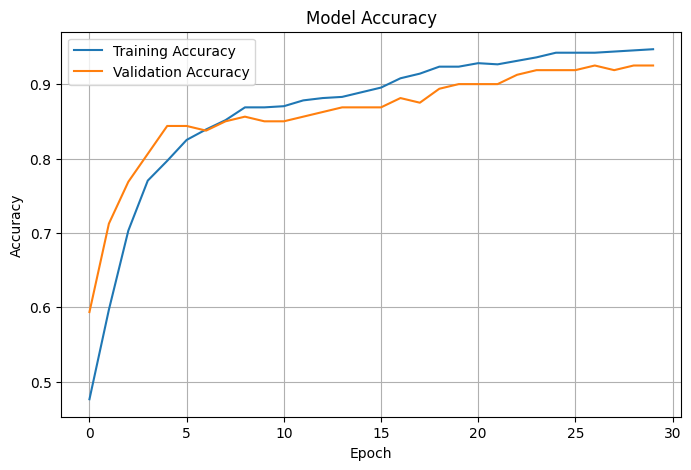

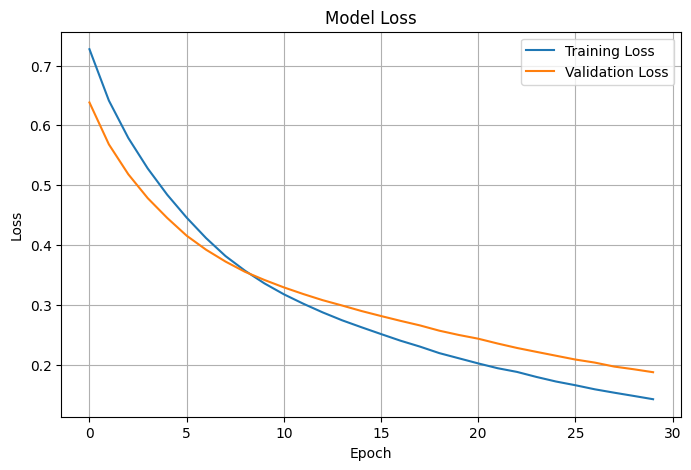

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# -----------------------------
# Create Synthetic Disease Data
# -----------------------------
np.random.seed(42)

n = 1000

age = np.random.randint(20, 80, n)
bp = np.random.randint(90, 180, n)
sugar = np.random.randint(70, 220, n)
cholesterol = np.random.randint(120, 320, n)

# Disease rule
disease = ((bp > 140) & (sugar > 140) | (cholesterol > 240)).astype(int)

data = pd.DataFrame({
    'Age': age,
    'BloodPressure': bp,
    'Sugar': sugar,
    'Cholesterol': cholesterol,
    'Disease': disease
})

print(data.head())

# -----------------------------
# Prepare Data
# -----------------------------
X = data[['Age','BloodPressure','Sugar','Cholesterol']]
y = data['Disease']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# -----------------------------
# Build Neural Network
# -----------------------------
model = Sequential([
    Dense(16, activation='relu', input_shape=(4,)),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# -----------------------------
# Train Model
# -----------------------------
history = model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

# -----------------------------
# Evaluate
# -----------------------------
loss, accuracy = model.evaluate(X_test, y_test)

print("\nTest Accuracy:", accuracy)

# -----------------------------
# Predict One Patient
# -----------------------------
sample = np.array([[50,160,180,260]])
sample = scaler.transform(sample)

prediction = model.predict(sample)

if prediction[0][0] > 0.5:
    print("Disease Detected")
else:
    print("Healthy")

# -----------------------------
# Plot Accuracy
# -----------------------------
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Model Accuracy")
plt.legend()
plt.grid(True)
plt.show()
print()
print()

# -----------------------------
# Plot Loss
# -----------------------------
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Model Loss")
plt.legend()
plt.grid(True)
plt.show()

MDP process


In [ ]:
# Markov Decision Process (MDP)

states = ['S1', 'S2', 'S3']
actions = ['A1', 'A2']

# Transition probabilities
transition_probabilities = {
    ('S1', 'A1', 'S2'): 0.6,
    ('S1', 'A1', 'S3'): 0.2,
    ('S1', 'A2', 'S2'): 0.4,
    ('S1', 'A2', 'S3'): 0.8,

    ('S2', 'A1', 'S1'): 0.7,
    ('S2', 'A1', 'S3'): 0.5,
    ('S2', 'A2', 'S1'): 0.3,
    ('S2', 'A2', 'S3'): 0.5,

    ('S3', 'A1', 'S1'): 0.9,
    ('S3', 'A1', 'S2'): 0.4,
    ('S3', 'A2', 'S1'): 0.1,
    ('S3', 'A2', 'S2'): 0.6
}

# Rewards
rewards = {
    ('S1', 'A1', 'S2'): 5,
    ('S1', 'A1', 'S3'): -1,
    ('S1', 'A2', 'S2'): 10,
    ('S1', 'A2', 'S3'): -5,

    ('S2', 'A1', 'S1'): 3,
    ('S2', 'A1', 'S3'): 2,
    ('S2', 'A2', 'S1'): 7,
    ('S2', 'A2', 'S3'): 1,

    ('S3', 'A1', 'S1'): 4,
    ('S3', 'A1', 'S2'): 0,
    ('S3', 'A2', 'S1'): 6,
    ('S3', 'A2', 'S2'): -2
}

print("="*45)
print("MARKOV DECISION PROCESS (MDP)")
print("="*45)

print("\nStates:")
print(states)

print("\nActions:")
print(actions)

print("\nNumber of States:", len(states))
print("Number of Actions:", len(actions))
print("Number of Transition Probabilities:", len(transition_probabilities))
print("Number of Rewards:", len(rewards))

print("\nTransition Probabilities")
print("-"*45)
for key, value in transition_probabilities.items():
    state, action, next_state = key
    print(f"P({next_state} | {state}, {action}) = {value}")

print("\nRewards")
print("-"*45)
for key, value in rewards.items():
    state, action, next_state = key
    print(f"R({state}, {action}, {next_state}) = {value}")

MARKOV DECISION PROCESS (MDP)

States:
['S1', 'S2', 'S3']

Actions:
['A1', 'A2']

Number of States: 3
Number of Actions: 2
Number of Transition Probabilities: 12
Number of Rewards: 12

Transition Probabilities
---------------------------------------------
P(S2 | S1, A1) = 0.6
P(S3 | S1, A1) = 0.2
P(S2 | S1, A2) = 0.4
P(S3 | S1, A2) = 0.8
P(S1 | S2, A1) = 0.7
P(S3 | S2, A1) = 0.5
P(S1 | S2, A2) = 0.3
P(S3 | S2, A2) = 0.5
P(S1 | S3, A1) = 0.9
P(S2 | S3, A1) = 0.4
P(S1 | S3, A2) = 0.1
P(S2 | S3, A2) = 0.6

Rewards
---------------------------------------------
R(S1, A1, S2) = 5
R(S1, A1, S3) = -1
R(S1, A2, S2) = 10
R(S1, A2, S3) = -5
R(S2, A1, S1) = 3
R(S2, A1, S3) = 2
R(S2, A2, S1) = 7
R(S2, A2, S3) = 1
R(S3, A1, S1) = 4
R(S3, A1, S2) = 0
R(S3, A2, S1) = 6
R(S3, A2, S2) = -2


In [ ]:
import numpy as np

states = ["S1", "S2", "S3"]

# Transition Probability Matrix for Action A1
P_A1 = np.array([
    [0.0, 0.6, 0.2],
    [0.7, 0.0, 0.5],
    [0.9, 0.4, 0.0]
])

# Transition Probability Matrix for Action A2
P_A2 = np.array([
    [0.0, 0.4, 0.8],
    [0.3, 0.0, 0.5],
    [0.1, 0.6, 0.0]
])

print("States:", states)

print("\nTransition Probability Matrix for Action A1")
print(P_A1)

print("\nTransition Probability Matrix for Action A2")
print(P_A2)

States: ['S1', 'S2', 'S3']

Transition Probability Matrix for Action A1
[[0.  0.6 0.2]
 [0.7 0.  0.5]
 [0.9 0.4 0. ]]

Transition Probability Matrix for Action A2
[[0.  0.4 0.8]
 [0.3 0.  0.5]
 [0.1 0.6 0. ]]


In [ ]:
import pandas as pd

# Reward data
reward_data = [
    ['S1', 'A1', 'S2', 5],
    ['S1', 'A1', 'S3', -1],
    ['S1', 'A2', 'S2', 10],
    ['S1', 'A2', 'S3', -5],
    ['S2', 'A1', 'S1', 3],
    ['S2', 'A1', 'S3', 2],
    ['S2', 'A2', 'S1', 7],
    ['S2', 'A2', 'S3', 1],
    ['S3', 'A1', 'S1', 4],
    ['S3', 'A1', 'S2', 0],
    ['S3', 'A2', 'S1', 6],
    ['S3', 'A2', 'S2', -2]
]

# Create DataFrame
reward_matrix = pd.DataFrame(
    reward_data,
    columns=["Current State", "Action", "Next State", "Reward"]
)

print("Reward Matrix")
print(reward_matrix)

Reward Matrix
   Current State Action Next State  Reward
0             S1     A1         S2       5
1             S1     A1         S3      -1
2             S1     A2         S2      10
3             S1     A2         S3      -5
4             S2     A1         S1       3
5             S2     A1         S3       2
6             S2     A2         S1       7
7             S2     A2         S3       1
8             S3     A1         S1       4
9             S3     A1         S2       0
10            S3     A2         S1       6
11            S3     A2         S2      -2


In [ ]:
# Transition probabilities
transition_prob = {
    ('S1', 'A1'): [('S2', 0.6), ('S3', 0.2)],
    ('S1', 'A2'): [('S2', 0.4), ('S3', 0.8)],
    ('S2', 'A1'): [('S1', 0.7), ('S3', 0.5)],
    ('S2', 'A2'): [('S1', 0.3), ('S3', 0.5)],
    ('S3', 'A1'): [('S1', 0.9), ('S2', 0.4)],
    ('S3', 'A2'): [('S1', 0.1), ('S2', 0.6)]
}

# Rewards
rewards = {
    ('S1', 'A1', 'S2'): 5,
    ('S1', 'A1', 'S3'): -1,
    ('S1', 'A2', 'S2'): 10,
    ('S1', 'A2', 'S3'): -5,
    ('S2', 'A1', 'S1'): 3,
    ('S2', 'A1', 'S3'): 2,
    ('S2', 'A2', 'S1'): 7,
    ('S2', 'A2', 'S3'): 1,
    ('S3', 'A1', 'S1'): 4,
    ('S3', 'A1', 'S2'): 0,
    ('S3', 'A2', 'S1'): 6,
    ('S3', 'A2', 'S2'): -2
}

print("=" * 70)
print("EXPECTED IMMEDIATE REWARD CALCULATION")
print("=" * 70)

for (state, action), transitions in transition_prob.items():

    print(f"\nState = {state}, Action = {action}")
    print("-" * 50)

    total = 0

    for next_state, prob in transitions:
        reward = rewards[(state, action, next_state)]
        value = prob * reward
        total += value

        print(f"P({next_state}|{state},{action}) × "
              f"R({state},{action},{next_state})")
        print(f"= {prob} × {reward} = {value:.2f}")

    print("-" * 50)
    print(f"Expected Immediate Reward = {total:.2f}")

EXPECTED IMMEDIATE REWARD CALCULATION

State = S1, Action = A1
--------------------------------------------------
P(S2|S1,A1) × R(S1,A1,S2)
= 0.6 × 5 = 3.00
P(S3|S1,A1) × R(S1,A1,S3)
= 0.2 × -1 = -0.20
--------------------------------------------------
Expected Immediate Reward = 2.80

State = S1, Action = A2
--------------------------------------------------
P(S2|S1,A2) × R(S1,A2,S2)
= 0.4 × 10 = 4.00
P(S3|S1,A2) × R(S1,A2,S3)
= 0.8 × -5 = -4.00
--------------------------------------------------
Expected Immediate Reward = 0.00

State = S2, Action = A1
--------------------------------------------------
P(S1|S2,A1) × R(S2,A1,S1)
= 0.7 × 3 = 2.10
P(S3|S2,A1) × R(S2,A1,S3)
= 0.5 × 2 = 1.00
--------------------------------------------------
Expected Immediate Reward = 3.10

State = S2, Action = A2
--------------------------------------------------
P(S1|S2,A2) × R(S2,A2,S1)
= 0.3 × 7 = 2.10
P(S3|S2,A2) × R(S2,A2,S3)
= 0.5 × 1 = 0.50
--------------------------------------------------
Expect

In [ ]:
import pandas as pd

summary = [
    ["S1", "A1", 2.8],
    ["S1", "A2", 0.0],
    ["S2", "A1", 3.1],
    ["S2", "A2", 2.6],
    ["S3", "A1", 3.6],
    ["S3", "A2", -0.6]
]

summary_df = pd.DataFrame(
    summary,
    columns=["State", "Action", "Expected Immediate Reward"]
)

print("\n" + "="*60)
print("EXPECTED IMMEDIATE REWARD SUMMARY")
print("="*60)
print(summary_df.to_string(index=False))


EXPECTED IMMEDIATE REWARD SUMMARY
State Action  Expected Immediate Reward
   S1     A1                        2.8
   S1     A2                        0.0
   S2     A1                        3.1
   S2     A2                        2.6
   S3     A1                        3.6
   S3     A2                       -0.6


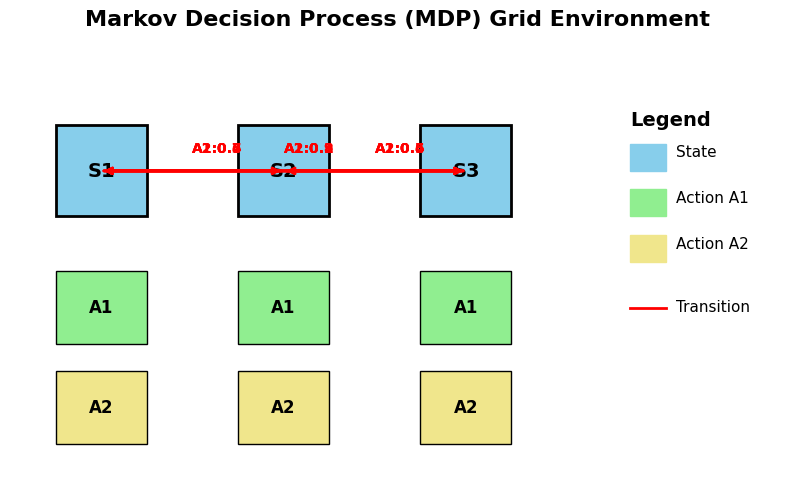

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# Create figure
fig, ax = plt.subplots(figsize=(10, 6))

# Grid positions
positions = {
    "S1": (0, 2),
    "S2": (2, 2),
    "S3": (4, 2)
}

# Draw state boxes
for state, (x, y) in positions.items():
    rect = Rectangle((x, y), 1, 1,
                     facecolor='skyblue',
                     edgecolor='black',
                     linewidth=2)
    ax.add_patch(rect)
    ax.text(x+0.5, y+0.5, state,
            ha='center', va='center',
            fontsize=14, fontweight='bold')

# Draw Action A1 boxes
for state, (x, y) in positions.items():
    rect = Rectangle((x, y-1.4), 1, 0.8,
                     facecolor='lightgreen',
                     edgecolor='black')
    ax.add_patch(rect)
    ax.text(x+0.5, y-1.0, "A1",
            ha='center', va='center',
            fontsize=12, fontweight='bold')

# Draw Action A2 boxes
for state, (x, y) in positions.items():
    rect = Rectangle((x, y-2.5), 1, 0.8,
                     facecolor='khaki',
                     edgecolor='black')
    ax.add_patch(rect)
    ax.text(x+0.5, y-2.1, "A2",
            ha='center', va='center',
            fontsize=12, fontweight='bold')

# Transition function
def transition(start, end, prob):
    x1, y1 = positions[start]
    x2, y2 = positions[end]

    ax.annotate("",
                xy=(x2+0.5, y2+0.5),
                xytext=(x1+0.5, y1+0.5),
                arrowprops=dict(
                    arrowstyle="->",
                    color="red",
                    lw=2))

    mx = (x1+x2)/2 + 0.5
    my = (y1+y2)/2 + 0.7

    ax.text(mx, my,
            prob,
            color="red",
            fontsize=10,
            fontweight="bold")

# Transitions for A1
transition("S1","S2","A1:0.6")
transition("S1","S3","A1:0.2")
transition("S2","S1","A1:0.7")
transition("S2","S3","A1:0.5")
transition("S3","S1","A1:0.9")
transition("S3","S2","A1:0.4")

# Transitions for A2
transition("S1","S2","A2:0.4")
transition("S1","S3","A2:0.8")
transition("S2","S1","A2:0.3")
transition("S2","S3","A2:0.5")
transition("S3","S1","A2:0.1")
transition("S3","S2","A2:0.6")

# Legend
ax.text(6.3,3.0,"Legend",fontsize=14,fontweight='bold')
ax.add_patch(Rectangle((6.3,2.5),0.4,0.3,color='skyblue'))
ax.text(6.8,2.65,"State",fontsize=11)

ax.add_patch(Rectangle((6.3,2.0),0.4,0.3,color='lightgreen'))
ax.text(6.8,2.15,"Action A1",fontsize=11)

ax.add_patch(Rectangle((6.3,1.5),0.4,0.3,color='khaki'))
ax.text(6.8,1.65,"Action A2",fontsize=11)

ax.plot([6.3,6.7],[1.0,1.0],color='red',lw=2)
ax.text(6.8,0.95,"Transition",fontsize=11)

# Formatting
ax.set_xlim(-0.5,8)
ax.set_ylim(-1,4)
ax.set_aspect('equal')
ax.axis('off')

plt.title("Markov Decision Process (MDP) Grid Environment",
          fontsize=16,
          fontweight='bold')

plt.show()

/tmp/ipykernel_600/3565413112.py:140: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_600/3565413112.py:140: UserWarning: Glyph 128998 (\N{LARGE BLUE SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_600/3565413112.py:140: UserWarning: Glyph 129001 (\N{LARGE GREEN SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_600/3565413112.py:140: UserWarning: Glyph 128999 (\N{LARGE ORANGE SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128998 (\N{LARGE BLUE SQUARE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129001 (\N{LARGE GREEN SQUARE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dis

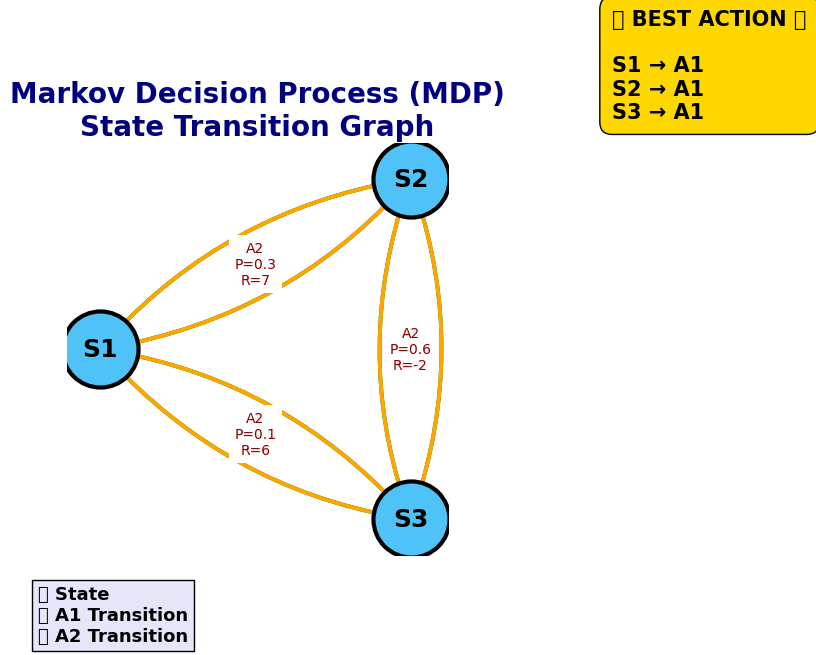

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

# -------------------------------
# Create MDP Graph
# -------------------------------
G = nx.MultiDiGraph()

# State positions (compact layout)
pos = {
    "S1": (0, 0),
    "S2": (2, 1.4),
    "S3": (2, -1.4)
}

states = ["S1", "S2", "S3"]

# Draw states
for s in states:
    G.add_node(s)

# A1 transitions
A1 = [
    ("S1","S2","A1\nP=0.6\nR=5"),
    ("S1","S3","A1\nP=0.2\nR=-1"),
    ("S2","S1","A1\nP=0.7\nR=3"),
    ("S2","S3","A1\nP=0.5\nR=2"),
    ("S3","S1","A1\nP=0.9\nR=4"),
    ("S3","S2","A1\nP=0.4\nR=0")
]

# A2 transitions
A2 = [
    ("S1","S2","A2\nP=0.4\nR=10"),
    ("S1","S3","A2\nP=0.8\nR=-5"),
    ("S2","S1","A2\nP=0.3\nR=7"),
    ("S2","S3","A2\nP=0.5\nR=1"),
    ("S3","S1","A2\nP=0.1\nR=6"),
    ("S3","S2","A2\nP=0.6\nR=-2")
]

for u, v, lbl in A1:
    G.add_edge(u, v, label=lbl, color="green")

for u, v, lbl in A2:
    G.add_edge(u, v, label=lbl, color="orange")

plt.figure(figsize=(10, 7))

# States
nx.draw_networkx_nodes(
    G, pos,
    node_size=3000,
    node_color="#4FC3F7",
    edgecolors="black",
    linewidths=3
)

nx.draw_networkx_labels(
    G, pos,
    font_size=18,
    font_weight="bold",
    font_color="black"
)

# Draw edges
for u, v, data in G.edges(data=True):

    color = data["color"]

    nx.draw_networkx_edges(
        G,
        pos,
        edgelist=[(u, v)],
        edge_color=color,
        arrows=True,
        arrowstyle="-|>",
        arrowsize=24,
        width=2.8,
        connectionstyle="arc3,rad=0.18"
    )

# Edge labels
edge_labels = {}
for u, v, k, data in G.edges(keys=True, data=True):
    edge_labels[(u, v, k)] = data["label"]

nx.draw_networkx_edge_labels(
    G,
    pos,
    edge_labels=edge_labels,
    font_size=10,
    font_color="darkred",
    rotate=False,
    bbox=dict(facecolor="white",
              edgecolor="none",
              alpha=0.9)
)

# Best Action Box
plt.text(
    3.3,
    1.9,
    "⭐ BEST ACTION ⭐\n\n"
    "S1 → A1\n"
    "S2 → A1\n"
    "S3 → A1",
    fontsize=15,
    fontweight="bold",
    bbox=dict(
        facecolor="gold",
        edgecolor="black",
        boxstyle="round,pad=0.6"
    )
)

# Legend
plt.text(
    -0.4,
    -2.4,
    "🟦 State\n"
    "🟩 A1 Transition\n"
    "🟧 A2 Transition",
    fontsize=13,
    fontweight="bold",
    bbox=dict(
        facecolor="lavender",
        edgecolor="black"
    )
)

plt.title(
    "Markov Decision Process (MDP)\nState Transition Graph",
    fontsize=20,
    fontweight="bold",
    color="navy"
)

plt.axis("off")
plt.tight_layout()
plt.show()